# MNIST in THRML

#### Dependencies:

In [1]:
!pip install jax networkx tensorflow tensorflow_datasets equinox matplotlib numpy thrml matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 5.7 MB/s eta 0:00:00


#### Imports
This is best done on a TPU or GPU, but CPU should be fine on most machines.

In [ ]:
import tensorflow as tf
import jax

tf.config.set_visible_devices([], 'GPU')
print(f"JAX Backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX Backend: gpu
Devices: [CudaDevice(id=0)]


In [ ]:
import jax
import jax.numpy as jnp
import tensorflow_datasets as tfds
import os
import tensorflow as tf
from thrml.block_management import Block
from thrml.block_sampling import (
    BlockGibbsSpec,
    sample_states,
    SamplingSchedule,
)
from thrml.models.discrete_ebm import SpinEBMFactor, SpinGibbsConditional
from thrml.pgm import SpinNode
from thrml.factor import FactorSamplingProgram
import matplotlib.pyplot as plt

#### --- 0. GLOBAL CONFIGURATION ---

In [ ]:
TILE_FACTOR = 1  #Label repetition on the output (e.g. 1 hot -> 10 hot) as in Laydevant et al. 2021. Doesn't really help. 
BATCH_SIZE = 32
INPUT_SIZE = 784 # MNIST flattened 
HIDDEN_SIZE = 64
OUTPUT_SIZE = 10 * TILE_FACTOR  

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#### --- 1. SAMPLER CONFIGURATION ---

In [ ]:
# Sampler will define how many steps to evolve the Ising lattice using Gibbs sampler. 
# It's shown later that for this task and network, the time to settle is well under 50 samples. 5-10 works fine.

N_SAMPLES = 3
schedule = SamplingSchedule(n_warmup=10, n_samples=N_SAMPLES, steps_per_sample=5)

#### --- 2. DATA PIPELINE ---

In [ ]:
def get_data(split='train', shuffle=True):
    ds = tfds.load('mnist', split=split, as_supervised=True)

    def preprocess(imgs, lbls):
        # 1. Flatten and binarize
        imgs = tf.reshape(imgs, [784])
        imgs = tf.cast(imgs, tf.float32) / 255.0
        bin_imgs = imgs > 0.5

        # 2. Encode as one-hot
        lbl_bits = tf.one_hot(lbls, 10)

        # 3. Tile the labels 10 times each index for Laydevant trick
        lbl_bits = tf.repeat(lbl_bits, TILE_FACTOR, axis=-1)
        lbl_bits = tf.cast(lbl_bits, tf.bool)

        return bin_imgs, lbl_bits

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(10000)
        ds = ds.repeat()

    ds = ds.batch(BATCH_SIZE, drop_remainder=True)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return iter(tfds.as_numpy(ds))

#### --- 3. TOPOLOGY ---

Block definitions: In THRML, we can define Blocks, which contain variables of the same variable type (e.g. continuous vs discrete) that do not interact. These are used to structure the sampling process. For geometrically complex graphs, this can be achieved with coloring. Because we have a simple tripartite graph without intra-layer interactions, our blocks will just be the three layers. For the clamped part of EqProp, we will clamp the input block.

Sampler: For the sampler, we will be using the pre-built SpinGibbsConditional sampler from THRML, which allows for efficient sampling of bernoulli distributed random variables. The spec and sampler will later be used to build the FactorSamplingProgram, which is callable to give the next state. 

In [ ]:
input_nodes = [SpinNode() for _ in range(INPUT_SIZE)]
hidden_nodes = [SpinNode() for _ in range(HIDDEN_SIZE)]
output_nodes = [SpinNode() for _ in range(OUTPUT_SIZE)]

input_block = Block(input_nodes)
hidden_block = Block(hidden_nodes)
output_block = Block(output_nodes)

spec = BlockGibbsSpec(free_super_blocks=[hidden_block, output_block], clamped_blocks=[input_block])
sampler = SpinGibbsConditional()

#### --- 4. CORE LOGIC ---

In [ ]:
def to_spin(b): return 2.0 * b.astype(jnp.float32) - 1.0

def get_tiled_argmax(bits): # bits dim: (Batch, 10 * TILE_FACTOR) or (10 * TILE_FACTOR,). 
    if bits.ndim == 1:
        reshaped = bits.reshape(10, TILE_FACTOR)
        return jnp.argmax(jnp.mean(reshaped, axis=1))
    else:
        reshaped = bits.reshape(-1, 10, TILE_FACTOR)
        return jnp.argmax(jnp.mean(reshaped, axis=2), axis=1)

h_idx, i_idx = jnp.meshgrid(jnp.arange(HIDDEN_SIZE), jnp.arange(INPUT_SIZE), indexing='ij')
o_idx, h_idx2 = jnp.meshgrid(jnp.arange(OUTPUT_SIZE), jnp.arange(HIDDEN_SIZE), indexing='ij')

# These define the dense connections of interactions between the spin nodes. i->input, h->hidden, o->output. 
# W1 are weights between i<>h, W2 between h<>o
h_dense_W1 = Block([hidden_nodes[i] for i in h_idx.ravel()])
i_dense_W1 = Block([input_nodes[j] for j in i_idx.ravel()])
o_dense_W2 = Block([output_nodes[i] for i in o_idx.ravel()])
h_dense_W2 = Block([hidden_nodes[j] for j in h_idx2.ravel()])

def train_step(W1, W2, Bh, Bo, input_data, target_data, init_h, init_o, key):
    k1, k2 = jax.random.split(key)

    # Now construct the factors, which represent the variables interacting (multiplied) and their learned Weight. 
    # THRML has a pre-built factor class for bernoulli distributed variables called SpinEBMFactor that we use.
    # Total of 4 factors: Weights and biases between the 3 layers. 
    f1 = SpinEBMFactor([h_dense_W1, i_dense_W1], W1.ravel())
    f2 = SpinEBMFactor([o_dense_W2, h_dense_W2], W2.ravel())
    fb_h = SpinEBMFactor([hidden_block], Bh)
    fb_o = SpinEBMFactor([output_block], Bo)

    # FREE PHASE
    # Clamp the input, let hidden and output settle. 
    prog_free = FactorSamplingProgram(spec, [sampler, sampler], [f1, f2, fb_h, fb_o], [])
    res_f = sample_states(k1, prog_free, schedule, [init_h, init_o],
                          state_clamp=[input_data], nodes_to_sample=[hidden_block, output_block])
    
    # Get the hidden and output states for free phase
    s_h_f_samples, s_o_f_samples = res_f[0], res_f[1]

    # NUDGED PHASE
    # Still clamp the now add a new Factor which defines the nudge interaction. Acts like a bias toward the true label
    # With strength Rho
    nudge_vals = jnp.where(target_data, RHO, -RHO)
    f_nudge = SpinEBMFactor([output_block], nudge_vals)
    prog_nudged = FactorSamplingProgram(spec, [sampler, sampler], [f1, f2, fb_h, fb_o, f_nudge], [])
    res_n = sample_states(k2, prog_nudged, schedule, [s_h_f_samples[-1], s_o_f_samples[-1]],
                          state_clamp=[input_data], nodes_to_sample=[hidden_block, output_block])

    # Get the hidden and output states for nudged phase. Convert to spins vals.                      
    s_h_n_samples, s_o_n_samples = res_n[0], res_n[1]

    sh_f, so_f = to_spin(s_h_f_samples), to_spin(s_o_f_samples)
    sh_n, so_n = to_spin(s_h_n_samples), to_spin(s_o_n_samples)
    si = to_spin(input_data)

    # Take the average over the batch for the grad computation
    avg_sh_n, avg_sh_f = jnp.mean(sh_n, axis=0), jnp.mean(sh_f, axis=0)

    # Take diff between correlations in nudged vs free (outer product between Input and Hidden). 
    # These will be all binary, can prob be optimized by just doing binary ops rather than fp LinAlg.
    # Divide by Rho per the EqProp Thm.
    grad_W1 = (jnp.outer(avg_sh_n, si) - jnp.outer(avg_sh_f, si)) / RHO
    # Same logic for rest
    stat_W2_n = jnp.mean(jax.vmap(jnp.outer)(so_n, sh_n), axis=0)
    stat_W2_f = jnp.mean(jax.vmap(jnp.outer)(so_f, sh_f), axis=0)
    grad_W2 = (stat_W2_n - stat_W2_f) / RHO
    avg_so_n, avg_so_f = jnp.mean(so_n, axis=0), jnp.mean(so_f, axis=0)
    grad_Bh = (avg_sh_n - avg_sh_f) / RHO
    grad_Bo = (avg_so_n - avg_so_f) / RHO

    # Gradients on the 2 Weight/Bias pairs, output first and last states, as well as last hidden state. 
    # These will be used for monitoring (accuracy) and state persistence.
    return grad_W1, grad_W2, grad_Bh, grad_Bo, so_f[0], s_h_f_samples[-1], s_o_f_samples[-1]

@jax.jit
def batch_step(W1, W2, Bh, Bo, imgs, labels, ph, po, key, learning_rate):
    keys = jax.random.split(key, BATCH_SIZE)
    # Batch the training step. Broadcast the Weights and Biases, Vectorize the Images, Labels, Persistence Chain, Output, RNG Keys
    gw1, gw2, gbh, gbo, preds, new_ph, new_po = jax.vmap(train_step, in_axes=(None, None, None, None, 0, 0, 0, 0, 0))(
        W1, W2, Bh, Bo, imgs, labels, ph, po, keys
    )

    # Apply the gradient update over the parameter
    def update_param(p, g):
        avg_g = jnp.mean(g, axis=0)
        return p + learning_rate * (jnp.clip(avg_g, -1.0, 1.0) - WEIGHT_DECAY * p)

    # Accuracy calculation using tiled argmax
    pred_idx = get_tiled_argmax(preds)
    label_idx = get_tiled_argmax(labels)
    accuracy = jnp.mean(pred_idx == label_idx)

    return update_param(W1, gw1), update_param(W2, gw2), update_param(Bh, gbh), update_param(Bo, gbo), new_ph, new_po, accuracy

#### --- VALIDATION LOGIC ---

In [ ]:
def val_step(W1, W2, Bh, Bo, input_data, init_h, init_o, key):
    f1 = SpinEBMFactor([h_dense_W1, i_dense_W1], W1.ravel())
    f2 = SpinEBMFactor([o_dense_W2, h_dense_W2], W2.ravel())
    fb_h = SpinEBMFactor([hidden_block], Bh)
    fb_o = SpinEBMFactor([output_block], Bo)

    prog_free = FactorSamplingProgram(spec, [sampler, sampler], [f1, f2, fb_h, fb_o], [])
    res_f = sample_states(key, prog_free, schedule, [init_h, init_o],
                          state_clamp=[input_data], nodes_to_sample=[hidden_block, output_block])
    return res_f[1][0]

@jax.jit
def batch_val(W1, W2, Bh, Bo, imgs, labels, ph, po, key):
    keys = jax.random.split(key, BATCH_SIZE)
    def val_unit(i, p_h, p_o, k):
        f1 = SpinEBMFactor([h_dense_W1, i_dense_W1], W1.ravel())
        f2 = SpinEBMFactor([o_dense_W2, h_dense_W2], W2.ravel())
        fb_h = SpinEBMFactor([hidden_block], Bh)
        fb_o = SpinEBMFactor([output_block], Bo)
        prog = FactorSamplingProgram(spec, [sampler, sampler], [f1, f2, fb_h, fb_o], [])

        res = sample_states(k, prog, schedule, [p_h, p_o],
                            state_clamp=[i], nodes_to_sample=[hidden_block, output_block])
        return res[1][0], res[0][-1], res[1][-1]

    preds, new_ph, new_po = jax.vmap(val_unit)(imgs, ph, po, keys)

    # Accuracy calculation using tiled argmax
    pred_idx = get_tiled_argmax(preds)
    label_idx = get_tiled_argmax(labels)
    acc = jnp.mean(pred_idx == label_idx)

    return acc, new_ph, new_po

def visualize_predictions(W1, W2, Bh, Bo, test_gen, key, num_images=5):
    imgs, labels = next(test_gen)
    sample_imgs_float = imgs[:num_images]
    sample_imgs_bool = (sample_imgs_float > 0.5)
    sample_labels = labels[:num_images]

    ph_val = jnp.zeros((num_images, HIDDEN_SIZE), dtype=jnp.bool_)
    po_val = jnp.zeros((num_images, OUTPUT_SIZE), dtype=jnp.bool_)

    keys = jax.random.split(key, num_images)
    preds_bits = jax.vmap(val_step, in_axes=(None, None, None, None, 0, 0, 0, 0))(
        W1, W2, Bh, Bo, sample_imgs_bool, ph_val, po_val, keys
    )

    true_labels = get_tiled_argmax(sample_labels)
    pred_labels = get_tiled_argmax(preds_bits)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(sample_imgs_float[i].reshape(28, 28), cmap='gray')
        color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("eqprop_predictions.png")
    plt.close()


def plot_metrics(train_accs, val_accs, n_epochs):
    epochs = range(1, n_epochs + 1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9))
    fig.suptitle("EqProp Training Metrics Over Epochs", fontsize=16)

    ax1.plot(epochs, train_accs, label='Training Accuracy', color='blue')
    ax1.set_title('Training Accuracy vs. Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.grid(True)

    ax2.plot(epochs, val_accs, label='Validation Accuracy', color='red')
    ax2.set_title('Validation Accuracy vs. Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("eqprop_training_curves.png")
    print("\nTraining curves saved to eqprop_training_curves.png (2 Rows, 1 Column)")
    plt.close()

#### --- 5. INITIALIZATION ---

In [ ]:
train_gen = get_data(split='train', shuffle=True)
test_gen = get_data(split='test', shuffle=False)

LEARNING_RATE = 0.01 # Uses an unusually high lr, tends to work best. 
RHO = 1.7 # This is the most unusual part; typically in EqProp we want a Rho that approaches 0 for validity. Convergence only found for 0.9<Rho<2.5 or so here.
WEIGHT_DECAY = 0.00 # Didn't find to be useful.
N_EPOCHS = 25
TRAIN_STEPS = 60000 // BATCH_SIZE
TEST_STEPS = 10000 // BATCH_SIZE

key = jax.random.PRNGKey(42)

# Scaled normal interaction (Weight) distribution to stabilize gradients. 
W1 = jax.random.normal(key, (HIDDEN_SIZE, INPUT_SIZE)) * (1.0 / jnp.sqrt(INPUT_SIZE))
W2 = jax.random.normal(key, (OUTPUT_SIZE, HIDDEN_SIZE)) * (1.0 / jnp.sqrt(HIDDEN_SIZE))
Bh, Bo = jnp.zeros(HIDDEN_SIZE), jnp.zeros(OUTPUT_SIZE)

# Persistence chains for the sampler
ph_train = jax.random.bernoulli(key, 0.5, (BATCH_SIZE, HIDDEN_SIZE))
po_train = jax.random.bernoulli(key, 0.5, (BATCH_SIZE, OUTPUT_SIZE))
ph_test = jax.random.bernoulli(key, 0.5, (BATCH_SIZE, HIDDEN_SIZE))
po_test = jax.random.bernoulli(key, 0.5, (BATCH_SIZE, OUTPUT_SIZE))


#### --- 6. TRAINING ---

In [ ]:

print("Starting MNIST EqProp Training...")
train_accs = []
val_accs = []

for epoch in range(N_EPOCHS):
    train_acc_accum = 0.0
    for step in range(TRAIN_STEPS):
        imgs, labels = next(train_gen)
        key, subkey = jax.random.split(key)

        # Get the updated weights and biases. Ph and Po are for maintaining persistence (https://www.cs.toronto.edu/~tijmen/pcd/pcd.pdf)
        # so that the MCMC doesn't start from random init every time. 
        W1, W2, Bh, Bo, ph_train, po_train, step_acc = batch_step(
            W1, W2, Bh, Bo, imgs, labels, ph_train, po_train, subkey, LEARNING_RATE
        )
        train_acc_accum += step_acc

        if step % 100 == 0 and step > 0:
            print(f"Epoch {epoch} | Step {step}/{TRAIN_STEPS} | Train Acc: {step_acc*100:.2f}%")

    avg_train_acc = (train_acc_accum / TRAIN_STEPS) * 100

    test_acc_accum = 0.0
    test_gen_for_validation = get_data(split='test', shuffle=False)
    for _ in range(TEST_STEPS):
        t_imgs, t_labels = next(test_gen_for_validation)
        key, subkey = jax.random.split(key)

        acc, ph_test, po_test = batch_val(W1, W2, Bh, Bo, t_imgs, t_labels, ph_test, po_test, subkey)
        test_acc_accum += acc

    avg_test_acc = (test_acc_accum / TEST_STEPS) * 100
    train_accs.append(avg_train_acc)
    val_accs.append(avg_test_acc)

    print(f"\n--- Epoch {epoch} Summary ---")
    print(f"Avg Train Acc: {avg_train_acc:.2f}%")
    print(f"Avg Test Acc:  {avg_test_acc:.2f}%")
    print("-" * 25 + "\n")
    if epoch % 5 == 0:
        visualize_predictions(W1, W2, Bh, Bo, test_gen, key)

print("\nEqProp Training Complete.")
plot_metrics(train_accs, val_accs, N_EPOCHS)

Starting MNIST EqProp Training (Tiling Factor: 1)...
Epoch 0 | Step 100/1875 | Train Acc: 12.50%
Epoch 0 | Step 200/1875 | Train Acc: 37.50%
Epoch 0 | Step 300/1875 | Train Acc: 12.50%
Epoch 0 | Step 400/1875 | Train Acc: 56.25%
Epoch 0 | Step 500/1875 | Train Acc: 40.62%
Epoch 0 | Step 600/1875 | Train Acc: 59.38%
Epoch 0 | Step 700/1875 | Train Acc: 34.38%
Epoch 0 | Step 800/1875 | Train Acc: 43.75%
Epoch 0 | Step 900/1875 | Train Acc: 53.12%
Epoch 0 | Step 1000/1875 | Train Acc: 40.62%
Epoch 0 | Step 1100/1875 | Train Acc: 40.62%
Epoch 0 | Step 1200/1875 | Train Acc: 34.38%
Epoch 0 | Step 1300/1875 | Train Acc: 53.12%
Epoch 0 | Step 1400/1875 | Train Acc: 53.12%
Epoch 0 | Step 1500/1875 | Train Acc: 56.25%
Epoch 0 | Step 1600/1875 | Train Acc: 65.62%
Epoch 0 | Step 1700/1875 | Train Acc: 62.50%
Epoch 0 | Step 1800/1875 | Train Acc: 65.62%

--- Epoch 0 Summary ---
Avg Train Acc: 48.17%
Avg Test Acc:  65.64%
-------------------------

Epoch 1 | Step 100/1875 | Train Acc: 71.88%
Epoch 

## Benchmarking and Tests:

Analyzing the flips / ns as in the original THRML docs: https://github.com/extropic-ai/thrml/blob/main/examples/02_spin_models.ipynb 

In [ ]:
# --- 6. FLIPS/NS BENCHMARKING ---

# This is basically all GPT code to mimic the flips / ns metric as in the THRML docs. 
# Future work could benchmark this versus other samplers and test between devices.

print("\n--- Starting Flips/ns Benchmark ---")
import time
# Calculate model size and steps
n_nodes = INPUT_SIZE + HIDDEN_SIZE + OUTPUT_SIZE
# Total Nodes = 784 + 32 + 10 = 826
n_total_steps_per_phase = schedule.n_warmup + (schedule.n_samples * schedule.steps_per_sample)
# Total Steps per Phase = 5 + (3 * 5) = 20
# A single batch_step runs two phases (Free and Nudged)
n_total_steps_per_batch_instance = n_total_steps_per_phase * 2
# Total Steps per Batch Instance = 20 * 2 = 40

# Use the trained BATCH_SIZE for the timing
timing_batch_size = BATCH_SIZE

# --- Setup Dummy Data for Timing ---
# Use a new master key for the benchmark section
timing_key_master = jax.random.PRNGKey(99)

# Generate dummy data and split the single key needed for batch_step
timing_key_master, subkey_img = jax.random.split(timing_key_master)
dummy_imgs = jax.random.bernoulli(subkey_img, 0.5, (timing_batch_size, INPUT_SIZE)).astype(jnp.bool_)

timing_key_master, subkey_label = jax.random.split(timing_key_master)
dummy_labels = jax.random.bernoulli(subkey_label, 0.5, (timing_batch_size, OUTPUT_SIZE)).astype(jnp.bool_)

timing_key_master, subkey_ph = jax.random.split(timing_key_master)
dummy_ph = jax.random.bernoulli(subkey_ph, 0.5, (timing_batch_size, HIDDEN_SIZE)).astype(jnp.bool_)
timing_key_master, subkey_po = jax.random.split(timing_key_master)
dummy_po = jax.random.bernoulli(subkey_po, 0.5, (timing_batch_size, OUTPUT_SIZE)).astype(jnp.bool_)

# This is the single key that batch_step expects.
timing_key_master, subkey_batch = jax.random.split(timing_key_master)

# Define a minimal jitted timing function to measure the core computation
@jax.jit
def timing_func(W1, W2, Bh, Bo, imgs, labels, ph, po, key_single, learning_rate):
    # Call batch_step and return the resulting parameters/states
    # key_single is the single PRNGKey expected by batch_step
    # We only care about the sampling speed, so we discard the accuracy/loss output
    return batch_step(W1, W2, Bh, Bo, imgs, labels, ph, po, key_single, learning_rate)[:6]

# JIT compilation run (warmup)
_ = timing_func(W1, W2, Bh, Bo, dummy_imgs, dummy_labels, dummy_ph, dummy_po, subkey_batch, LEARNING_RATE)
jax.block_until_ready(_)

# Timing run
start_time = time.time()
_ = timing_func(W1, W2, Bh, Bo, dummy_imgs, dummy_labels, dummy_ph, dummy_po, subkey_batch, LEARNING_RATE)
jax.block_until_ready(_)
stop_time = time.time()

time_s = stop_time - start_time
# Total Flips = Chains * Nodes * Steps_per_chain
total_flips = timing_batch_size * n_nodes * n_total_steps_per_batch_instance
flips_per_ns = total_flips / (time_s * 1e9)

print(f"Model Configuration:")
print(f"  Total Nodes (DOF): {n_nodes}")
print(f"  Sampling Steps per Phase (Warmup+Samples): {n_total_steps_per_phase}")
print(f"  Total Steps per Batch Instance (Free + Nudged): {n_total_steps_per_batch_instance}")
print(f"  Parallel Chains (Batch Size): {timing_batch_size}")

print(f"\nBenchmark Results:")
print(f"  Total Flips in one batch_step: {total_flips / 1e6:.2f} million flips")
print(f"  Time taken for one batch_step: {time_s * 1e3:.2f} ms")
print(f"  Flips/ns: {flips_per_ns:.2f}")
print(f"  Flips/s: {total_flips / time_s / 1e9:.2f} billion flips per second")


--- Starting Flips/ns Benchmark ---
Model Configuration:
  Total Nodes (DOF): 858
  Sampling Steps per Phase (Warmup+Samples): 25
  Total Steps per Batch Instance (Free + Nudged): 50
  Parallel Chains (Batch Size): 32

Benchmark Results:
  Total Flips in one batch_step: 1.37 million flips
  Time taken for one batch_step: 3.48 ms
  Flips/ns: 0.40
  Flips/s: 0.40 billion flips per second


#### Confidence as a Function of Steps

How does confidence in the answer change as a function of the sampling steps? How many sampling steps do we really need for this dataset and architecture?


Generating convergence graph over 100 steps...


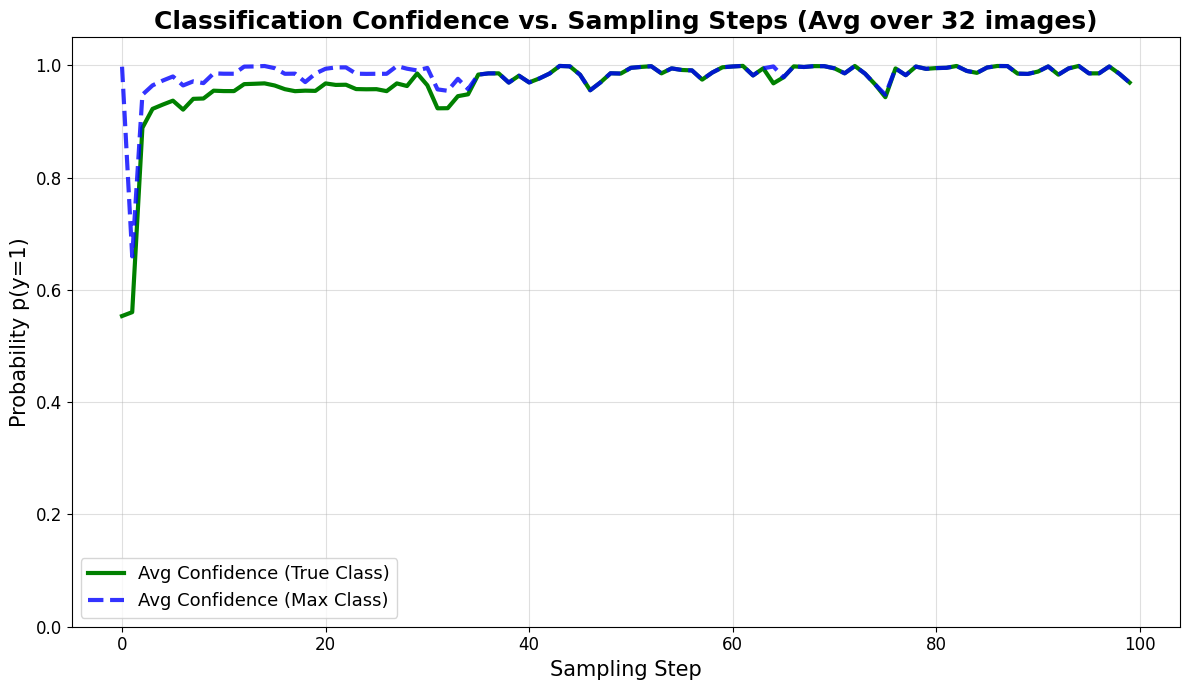

In [ ]:
def analyze_convergence(W1, W2, Bh, Bo, test_gen, key, n_steps=100):
    trajectory_schedule = SamplingSchedule(
        n_warmup=0,
        n_samples=n_steps,
        steps_per_sample=1
    )

    imgs, labels = next(test_gen)
    imgs_bool = imgs > 0.5

    key, init_key = jax.random.split(key)
    p_h_init = jax.random.bernoulli(init_key, 0.5, (BATCH_SIZE, HIDDEN_SIZE))
    p_o_init = jax.random.bernoulli(init_key, 0.5, (BATCH_SIZE, OUTPUT_SIZE))

    def run_single_chain(k, h_init, o_init, img_clamped):
        f1 = SpinEBMFactor([h_dense_W1, i_dense_W1], W1.ravel())
        f2 = SpinEBMFactor([o_dense_W2, h_dense_W2], W2.ravel())
        fb_h = SpinEBMFactor([hidden_block], Bh)
        fb_o = SpinEBMFactor([output_block], Bo)

        prog = FactorSamplingProgram(spec, [sampler, sampler], [f1, f2, fb_h, fb_o], [])

        res = sample_states(
            k,
            prog,
            trajectory_schedule,
            [h_init, o_init],
            state_clamp=[img_clamped],
            nodes_to_sample=[hidden_block, output_block]
        )
        return res[0], res[1]


    keys = jax.random.split(key, BATCH_SIZE)
    h_hist_bool, _ = jax.vmap(run_single_chain)(keys, p_h_init, p_o_init, imgs_bool)
    h_hist_spin = 2.0 * h_hist_bool.astype(jnp.float32) - 1.0

    # Calculate Field entering Output units
    fields_o = jnp.dot(h_hist_spin, W2.T) + Bo

    # Convert to probabilities: P(y=1) = sigmoid(2 * field)
    probs_o = jax.nn.sigmoid(2.0 * fields_o)

    if TILE_FACTOR > 1:
        # Reshape to (Batch, Steps, 10, TILE_FACTOR)
        probs_reshaped = probs_o.reshape(BATCH_SIZE, n_steps, 10, TILE_FACTOR)
        class_probs = jnp.mean(probs_reshaped, axis=3) # (Batch, Steps, 10)
    else:
        class_probs = probs_o # (Batch, Steps, 10)

    # Confidence(True)
    true_labels_idx = get_tiled_argmax(labels) # (Batch,)

    # Extract prob of true class for each batch element
    true_class_conf = jnp.take_along_axis(
        class_probs,
        true_labels_idx[:, None, None], 
        axis=2
    ).squeeze(2) #(Batch, Steps)

    # B. Confidence of the Predicted / ArgMax Class
    pred_class_conf = jnp.max(class_probs, axis=2) # (Batch, Steps)
    avg_true_conf = jnp.mean(true_class_conf, axis=0)
    avg_pred_conf = jnp.mean(pred_class_conf, axis=0)

    steps_range = jnp.arange(n_steps)

    plt.figure(figsize=(12, 7))
    plt.plot(steps_range, avg_true_conf, label='Avg Confidence (True Class)', color='green', linewidth=3)
    plt.plot(steps_range, avg_pred_conf, label='Avg Confidence (Max Class)', color='blue', linestyle='--', alpha=0.8, linewidth=3)
    plt.title(f"Classification Confidence vs. Sampling Steps (Avg over {BATCH_SIZE} images)", fontsize=18, fontweight='bold')
    plt.xlabel("Sampling Step", fontsize=15)
    plt.ylabel("Probability p(y=1)", fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.4, linestyle='-')
    plt.legend(fontsize=13) # Increase legend font size
    plt.tight_layout()
    plt.show()

analyze_convergence(W1, W2, Bh, Bo, test_gen, key)

Most of the confidence comes from the first few steps. 